# Layers 1 & 2 Cross-Head Mean-Attention Intervention — Multiple Query Positions

Copy of `layer_1_and_2_mean_attention_ablation.ipynb`, adapted to a longer **fixed
sentence** and to **three query positions** instead of one.

**Sentence** (tokenised with `add_special_tokens=False`):

> "Florida State University is ranked No. 21 among top public universities in the
> United States according to the U.S. News & World Report."

**Intervention.** For each query position `q ∈ {12, 18, last}`, and for every key
position `k = 0 … q` (all causally-visible keys up to *and including* `q` — "replace
all the attention score up to that token position"), compute the **mean across all 32
heads** of that key's post-softmax attention score at `q`, then write that
head-averaged value back into **every head**. All 32 heads then share one identical,
data-dependent distribution over keys `0 … q`. Exactly as in the source notebook this
is applied only within **layer 1 and layer 2** (Dr. Liu's 1-indexed convention = HF
0-indexed `model.model.layers[0]` and `[1]`, i.e. `LAYERS_TO_TEST = [0, 1]`).

Each query position is run as its own forward pass / its own condition. For each one
(plus an un-patched baseline) we run the usual diagnostics on the resulting
residual-stream stack: the layer-2 gate vector, the top-k |activation| vs. layer
curve, the massive-activation table, and the 3D (feature dim × token position ×
|activation|) bar plot — to show where massive activations sit under this
intervention.

**Why patch `LlamaAttention.forward` (not the mask kwarg).** "Replace with the
cross-head mean" is a *post-softmax* edit with no additive-mask equivalent, so we
monkeypatch the forward method itself — identical to the stock method up through
softmax, then the cross-head averaging, then the value-weighted sum. transformers
4.46.3 computes eager attention inline in this method (no standalone
`eager_attention_forward` to patch).

**Cross-head, not cross-key.** Averaging a single head's own post-softmax weights over
keys is forced to `1/(q+1)` regardless of data. Averaging *across heads* at a fixed
key has no such constraint, so the shared row genuinely reflects the model's learned
attention pattern.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import contextlib
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from transformers import AutoModelForCausalLM, AutoTokenizer
import transformers.models.llama.modeling_llama as llama_modeling

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

# 0-indexed HF layers to intervene on -- SAME as the source notebook.
# LAYERS_TO_TEST[0] == 0 -> Dr. Liu's 1-indexed "layer 1"
# LAYERS_TO_TEST[1] == 1 -> Dr. Liu's 1-indexed "layer 2"
LAYERS_TO_TEST = [0, 1]
LAYER_LABELS = {0: "layer 1", 1: "layer 2"}

NEURON_IDX = 2427          # MA-implicated gate neuron (same as source)

# Every gate number in this notebook is read at this ONE layer, whichever layer the
# patch is applied to. gate_proj.weight differs per layer, so `gate_vec[NEURON_IDX]`
# at layer 0 and at layer 1 are unrelated quantities -- NEURON_IDX was identified at
# HF layer 1 ("layer 2"), which is the only place that index means anything. Holding
# the read-out layer fixed while varying the PATCHED layer is what makes the
# L1-only / L2-only / combined columns comparable to each other and to the baseline.
GATE_READOUT_LAYER = 1     # HF index 1 == Dr. Liu's "layer 2"
assert GATE_READOUT_LAYER in LAYERS_TO_TEST, (
    "GATE_READOUT_LAYER must be one of LAYERS_TO_TEST -- Steps 2b/3 index results[q][GATE_READOUT_LAYER]"
)

# Query positions to intervene on / read out. The last token position is appended
# after tokenisation (next-but-one cell). For query position q the replaced key
# positions are 0 .. q inclusive.
EXPLICIT_QUERY_POSITIONS = [12, 18]

OUTPUT_DIR = "outputs/layers_1_and_2_mean_attn_intervention"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(0)


In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    attn_implementation="eager",  # required: LlamaAttention.forward is the patch target
).to(DEVICE)
model.eval()
print(model.config.num_hidden_layers, "layers | hidden_size:", model.config.hidden_size)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

32 layers | hidden_size: 4096


## Prepare input — the fixed sentence

`add_special_tokens=False` (same convention as the source notebook and the
Massive-Activations reproduction notebook), with an explicit BOS check. We then build
`QUERY_POSITIONS = [12, 18, last]` and, for each `q`, the key set `0 … q`.

In [3]:
PROMPT = ("Florida State University is ranked No. 21 among top public universities "
          "in the United States according to the U.S. News & World Report.")

BOS_ID = tokenizer.bos_token_id
ids = tokenizer.encode(PROMPT, add_special_tokens=False)
assert ids[0] != BOS_ID, "First token unexpectedly matches BOS id -- check tokenizer/prompt"

LAST_POS = len(ids) - 1
assert LAST_POS > max(EXPLICIT_QUERY_POSITIONS), (
    f"Prompt only tokenises to {len(ids)} tokens; need > {max(EXPLICIT_QUERY_POSITIONS) + 1}."
)
QUERY_POSITIONS = [q for q in EXPLICIT_QUERY_POSITIONS if q < LAST_POS] + [LAST_POS]

# "replace all the attention score up to that token position" -> keys 0..q inclusive
KEY_POSITIONS_BY_QPOS = {q: list(range(q + 1)) for q in QUERY_POSITIONS}

input_ids = torch.tensor([ids], device=DEVICE)
tokens_decoded = [tokenizer.decode([t]) for t in ids]

print(f"{len(ids)} tokens")
for j, tok in enumerate(tokens_decoded):
    mark = "   <-- query pos" if j in QUERY_POSITIONS else ""
    print(f"  [{j:2d}] {tok!r}{mark}")
print("\nQUERY_POSITIONS:", QUERY_POSITIONS)
for q in QUERY_POSITIONS:
    print(f"  q={q:2d} -> replace keys 0..{q}  (token {tokens_decoded[q]!r})")

28 tokens
  [ 0] 'Florida'
  [ 1] ' State'
  [ 2] ' University'
  [ 3] ' is'
  [ 4] ' ranked'
  [ 5] ' No'
  [ 6] '.'
  [ 7] ' '
  [ 8] '21'
  [ 9] ' among'
  [10] ' top'
  [11] ' public'
  [12] ' universities'   <-- query pos
  [13] ' in'
  [14] ' the'
  [15] ' United'
  [16] ' States'
  [17] ' according'
  [18] ' to'   <-- query pos
  [19] ' the'
  [20] ' U'
  [21] '.S'
  [22] '.'
  [23] ' News'
  [24] ' &'
  [25] ' World'
  [26] ' Report'
  [27] '.'   <-- query pos

QUERY_POSITIONS: [12, 18, 27]
  q=12 -> replace keys 0..12  (token ' universities')
  q=18 -> replace keys 0..18  (token ' to')
  q=27 -> replace keys 0..27  (token '.')


## Helpers — cross-head mean-replace patch and activation capture

`make_mean_replace_forward` is a drop-in replacement for
`transformers.models.llama.modeling_llama.LlamaAttention.forward`. It is identical to
the stock 4.46.3 method up through softmax; then, for any layer in `layers_to_patch`
and any `(query_pos, key_positions)` entry in `interventions`, the attention weights
at `query_pos` over `key_positions` are averaged **across the head dimension**
(independently per key position) and that head-averaged value is written back into
every head. Monkeypatching the class attribute takes effect for every decoder layer
at once (they share the class).

`capture_activations` runs one forward pass (optionally with the patch active), and
returns per-layer / per-position gate + attention read-outs plus the full
`output_hidden_states` residual-stream stack captured *under* that intervention.

`print_attn_matrix` / `print_attn_row` (next cell) dump a full `(32 heads x K keys)`
post-softmax block as an aligned table — the same verification the source notebook did
with `np.printoptions`, but with a key-position header, since the blocks here are up to
28 keys wide.


In [4]:
_ORIGINAL_LLAMA_ATTENTION_FORWARD = llama_modeling.LlamaAttention.forward


def make_mean_replace_forward(layers_to_patch, interventions):
    # interventions: {query_pos: iterable of key positions to cross-head-mean-replace}.
    interventions = {int(q): torch.as_tensor(list(k), dtype=torch.long)
                     for q, k in interventions.items()}

    def patched_forward(
        self,
        hidden_states,
        attention_mask=None,
        position_ids=None,
        past_key_value=None,
        output_attentions=False,
        use_cache=False,
        cache_position=None,
        position_embeddings=None,
        **kwargs,
    ):
        bsz, q_len, _ = hidden_states.size()

        query_states = self.q_proj(hidden_states)
        key_states = self.k_proj(hidden_states)
        value_states = self.v_proj(hidden_states)

        query_states = query_states.view(bsz, q_len, self.num_heads, self.head_dim).transpose(1, 2)
        key_states = key_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        value_states = value_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        if position_embeddings is None:
            cos, sin = self.rotary_emb(value_states, position_ids)
        else:
            cos, sin = position_embeddings
        query_states, key_states = llama_modeling.apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_value is not None:
            cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
            key_states, value_states = past_key_value.update(key_states, value_states, self.layer_idx, cache_kwargs)

        key_states = llama_modeling.repeat_kv(key_states, self.num_key_value_groups)
        value_states = llama_modeling.repeat_kv(value_states, self.num_key_value_groups)

        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3)) / (self.head_dim ** 0.5)
        if attention_mask is not None:
            causal_mask = attention_mask[:, :, :, : key_states.shape[-2]]
            attn_weights = attn_weights + causal_mask
        attn_weights = F.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)

        layer_idx = getattr(self, "layer_idx", None)
        if layer_idx in layers_to_patch:
            for q_pos, key_idx in interventions.items():
                idx = key_idx.to(attn_weights.device)
                # (batch, heads, K) -- every head's own scores at these keys
                vals = attn_weights[:, :, q_pos, idx]
                num_heads = vals.shape[1]
                # mean ACROSS HEADS (dim=1), independently per key position -- NOT across keys.
                mean_over_heads = vals.mean(dim=1, keepdim=True)
                attn_weights[:, :, q_pos, idx] = mean_over_heads.expand(-1, num_heads, -1)

        attn_weights = F.dropout(attn_weights, p=self.attention_dropout, training=self.training)
        attn_output = torch.matmul(attn_weights, value_states)

        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(bsz, q_len, -1)
        attn_output = self.o_proj(attn_output)

        if not output_attentions:
            attn_weights = None

        return attn_output, attn_weights, past_key_value

    return patched_forward


@contextlib.contextmanager
def mean_replace_attention(layers_to_patch, interventions):
    llama_modeling.LlamaAttention.forward = make_mean_replace_forward(set(layers_to_patch), interventions)
    try:
        yield
    finally:
        llama_modeling.LlamaAttention.forward = _ORIGINAL_LLAMA_ATTENTION_FORWARD


def capture_activations(model, input_ids, capture_layers, readout_positions,
                        mean_replace_layers=None, interventions=None):
    # One forward pass. If mean_replace_layers is given, the cross-head mean-replace
    # patch is active for those HF layer indices, driven by `interventions`
    # ({query_pos: key positions}). Returns (results, hidden_states):
    #   - results[L][q] = {'gate': (14336,), 'attn': (n_heads, seq)} for every L in
    #     capture_layers and q in readout_positions.
    #   - hidden_states: tuple of length num_layers + 1, each (1, T, d) float32 CPU
    #     tensor -- hidden_states[0] is the embedding output, hidden_states[l] the
    #     residual stream after decoder layer l -- captured under whatever intervention
    #     is active this pass (same format as output_hidden_states=True elsewhere).
    captured = {}
    handles = []

    def make_mlp_input_hook(L):
        def hook(module, args):
            captured[('mlp_input', L)] = args[0].detach()
        return hook

    for L in capture_layers:
        handles.append(model.model.layers[L].mlp.register_forward_pre_hook(make_mlp_input_hook(L)))

    cm = (
        mean_replace_attention(mean_replace_layers, interventions or {})
        if mean_replace_layers is not None
        else contextlib.nullcontext()
    )

    try:
        with cm, torch.no_grad():
            out = model(input_ids=input_ids, output_attentions=True, output_hidden_states=True)
    finally:
        for h in handles:
            h.remove()

    results = {}
    for L in capture_layers:
        W_gate = model.model.layers[L].mlp.gate_proj.weight.detach().to(torch.float32)
        per_pos = {}
        for q in readout_positions:
            x = captured[('mlp_input', L)][0, q, :].to(torch.float32)
            gate_vec = x @ W_gate.T
            attn_pattern_L = out.attentions[L][0, :, q, :].to(torch.float32)
            per_pos[q] = dict(gate=gate_vec.cpu().numpy(), attn=attn_pattern_L.cpu().numpy())
        results[L] = per_pos

    hidden_states = tuple(h.detach().to(torch.float32).cpu() for h in out.hidden_states)
    return results, hidden_states

In [5]:
def print_attn_matrix(mat, title, key_offset=0, precision=4):
    """Print a (n_heads, K) post-softmax attention block as an aligned table.

    Rows are heads, columns are key positions `key_offset .. key_offset + K - 1`.
    Same content the source notebook dumped with `np.printoptions`, but with an
    explicit key-position header row, because the blocks here are 13/19/28 keys
    wide instead of 3 and raw numpy wrapping makes them unreadable.
    """
    mat = np.asarray(mat)
    n_heads, K = mat.shape
    w = precision + 4
    print(title)
    print(" " * 6 + "".join(f"{key_offset + k:>{w}d}" for k in range(K)) + "   <- key pos")
    for h in range(n_heads):
        print(f"h{h:<5d}" + "".join(f"{mat[h, k]:>{w}.{precision}f}" for k in range(K)))


def print_attn_row(row, label, precision=4):
    """One (K,) row printed in the same column alignment as print_attn_matrix."""
    w = precision + 4
    print(f"{label[:6]:<6}" + "".join(f"{v:>{w}.{precision}f}" for v in np.asarray(row)))


## Steps 1–2 — Independent single-layer cross-head mean-replace, per query position

For each query position `q` and each `L` in `LAYERS_TO_TEST`: a baseline pass (no
patch) and an intervention pass (cross-head mean-replace at layer `L` only, keys
`0 … q`), each a fresh forward call.

**Two read-out points per pass, and they are not the same thing.**

- The **attention block** is read *at the patched layer* `L` — that is where the edit
  happens, so that is the only place it can be verified.
- The **gate vector** is always read at `GATE_READOUT_LAYER` (HF index 1, "layer 2"),
  regardless of which layer was patched. `gate_proj.weight` is a different matrix at
  every layer, so `gate[2427]` at layer 0 and `gate[2427]` at layer 1 are unrelated
  numbers; only the layer where the neuron was identified is meaningful. Varying the
  *patch* layer while pinning the *read-out* layer is what makes the `L1-only` /
  `L2-only` / `combined` columns in Step 3 comparable.

Both full `(32 heads × (q+1) keys)` blocks are printed so the edit can be checked by
eye. What to look for:

1. Every one of the 32 rows in the **intervention** block is identical.
2. That shared row equals the column-wise (cross-head) mean of the **baseline** block
   — printed underneath both blocks as `mean` for direct comparison.
3. The shared row still sums to **1.0** over keys `0 … q`. This is a real check, not a
   tautology: each baseline head row sums to 1 over its causal support, so the
   cross-head mean sums to 1 *only if* `key_positions` covers exactly that support.
   A sum ≠ 1 means the key set was built wrong.

Only the single-layer condition admits check 2 at all: the patch is post-softmax at
layer `L`, so layer `L`'s inputs are untouched and its pre-patch softmax is exactly the
baseline's. The combined condition in Step 2b has no such ground truth.


In [6]:
results = {}   # results[q][L] -> {'baseline', 'intervention', 'gate_readout_*'};  results[q]['combined'] added later
HIDDEN_STATES_DIR = os.path.join(OUTPUT_DIR, "hidden_states")
os.makedirs(HIDDEN_STATES_DIR, exist_ok=True)

for q in QUERY_POSITIONS:
    key_pos = KEY_POSITIONS_BY_QPOS[q]
    results[q] = {}
    print(f"\n########## query pos {q}  (token {tokens_decoded[q]!r}) -- replace keys 0..{q} ##########")

    for L in LAYERS_TO_TEST:
        label = LAYER_LABELS[L]
        print(f"\n=== q={q}, patch {label} (HF index {L}) only "
              f"| gate read-out @ HF layer {GATE_READOUT_LAYER} ({LAYER_LABELS[GATE_READOUT_LAYER]}) ===")

        # Capture at BOTH the patched layer (to verify the attention edit where it
        # happens) and the fixed gate read-out layer (so every condition's gate number
        # is measured through the same gate_proj matrix and is therefore comparable).
        cap = sorted({L, GATE_READOUT_LAYER})
        baseline, _ = capture_activations(model, input_ids, capture_layers=cap, readout_positions=[q])
        intervention, _ = capture_activations(
            model, input_ids, capture_layers=cap, readout_positions=[q],
            mean_replace_layers={L}, interventions={q: key_pos},
        )

        # ---- attention verification: read AT the patched layer L ------------------
        baseline_attn = baseline[L][q]['attn'][:, :q + 1]
        expected_row = baseline_attn.mean(axis=0)   # cross-head mean, per key position
        interv_attn = intervention[L][q]['attn'][:, :q + 1]

        print_attn_matrix(
            baseline_attn,
            f"\nbaseline attn pattern at {label}, query pos {q} (per head, keys 0..{q}):")
        print_attn_row(expected_row, "mean")
        print("  ^ column-wise mean across heads = expected shared row after the patch")

        print_attn_matrix(
            interv_attn,
            f"\nintervention attn pattern at {label}, query pos {q} (per head, keys 0..{q}):")
        print_attn_row(expected_row, "mean")
        print("  ^ baseline cross-head mean again -- every row above should match it")

        rows_identical = np.allclose(interv_attn, interv_attn[0], atol=1e-3)
        matches_expected = np.allclose(interv_attn[0], expected_row, atol=1e-3)
        max_head_spread = float(np.abs(interv_attn - interv_attn[0]).max())
        max_dev_from_mean = float(np.abs(interv_attn - expected_row).max())
        print(f"\n-> all 32 heads identical: {rows_identical} (max |head - head0| = {max_head_spread:.2e})")
        print(f"-> matches cross-head baseline mean: {matches_expected} "
              f"(max |patched - mean| = {max_dev_from_mean:.2e})")
        # each baseline head row sums to 1 over its causal support, so the cross-head
        # mean does too -- iff key_positions covers exactly keys 0..q. Sum != 1 => bad key set.
        print(f"-> row sum over keys 0..{q}: baseline head-0 = {baseline_attn[0].sum():.6f} | "
              f"patched head-0 = {interv_attn[0].sum():.6f}  (both should be 1.0)")
        # keys strictly after q are causally masked and must stay exactly zero
        tail_max = float(np.abs(intervention[L][q]['attn'][:, q + 1:]).max()) if q + 1 < len(ids) else 0.0
        print(f"-> max attn on causally-masked keys {q + 1}..{len(ids) - 1}: {tail_max:.2e}  (should be 0)")

        # ---- gate read-out: ALWAYS at GATE_READOUT_LAYER, never at L --------------
        gate_base = baseline[GATE_READOUT_LAYER][q]['gate']
        gate_interv = intervention[GATE_READOUT_LAYER][q]['gate']
        print(f"gate@L{GATE_READOUT_LAYER}[{NEURON_IDX}] baseline     = {gate_base[NEURON_IDX]:.4f}")
        print(f"gate@L{GATE_READOUT_LAYER}[{NEURON_IDX}] intervention = {gate_interv[NEURON_IDX]:.4f}"
              f"   (patch applied at HF layer {L})")

        results[q][L] = {
            # read-outs AT the patched layer -- the attention blocks verified above
            'baseline': baseline[L][q],
            'intervention': intervention[L][q],
            # gate read at the FIXED layer, so L1-only / L2-only / combined are comparable
            'gate_readout_baseline': gate_base,
            'gate_readout_intervention': gate_interv,
        }



########## query pos 12  (token ' universities') -- replace keys 0..12 ##########

=== q=12, patch layer 1 (HF index 0) only | gate read-out @ HF layer 1 (layer 2) ===

baseline attn pattern at layer 1, query pos 12 (per head, keys 0..12):
             0       1       2       3       4       5       6       7       8       9      10      11      12   <- key pos
h0      0.0247  0.0170  0.0371  0.0225  0.0574  0.0271  0.1338  0.0574  0.0630  0.2656  0.1660  0.0918  0.0371
h1      0.0144  0.0117  0.0182  0.0165  0.0311  0.0117  0.5469  0.1167  0.0144  0.0286  0.0330  0.0471  0.1079
h2      0.0000  0.0000  0.0000  0.0001  0.0005  0.0002  0.0006  0.0003  0.0001  0.0022  0.1338  0.7695  0.0918
h3      0.0135  0.0145  0.0156  0.0183  0.0403  0.0069  0.5156  0.0981  0.0236  0.0299  0.0291  0.0879  0.1079
h4      0.0078  0.0078  0.0073  0.1709  0.0080  0.0124  0.3301  0.2344  0.0035  0.0574  0.0408  0.0947  0.0250
h5      0.0093  0.0085  0.0085  0.1436  0.0071  0.0103  0.2520  0.1963  0.0036  

## Step 2b — Combined condition: both layers mean-replaced in the same forward pass

For each query position, patch layers 1 and 2 simultaneously
(`mean_replace_layers={0, 1}`) in one forward pass and read the gate out at
`GATE_READOUT_LAYER` — the same layer Steps 1–2 used, so `combined` sits in the same
units as `L1-only` and `L2-only`. Because layer 2 now processes a residual stream that
already reflects layer 1's mean-replace, this isolates whether layer 1's perturbation
propagates forward into layer 2's gate read-out on top of layer 2's own local
intervention. The full residual-stream stack from each of these passes is what the
massive-activation diagnostics below run on. An un-patched baseline stack is captured
too.

**Reading the printed block.** The two structural invariants still hold — all 32 rows
identical, shared row summing to 1. The shared row is **not** expected to equal the
un-patched layer-2 cross-head mean, though, and that is not a failure: layer 1's patch
changes layer 2's *inputs*, so layer 2's pre-patch softmax genuinely differs from
baseline. That gap is printed as `||shared_row − unpatched L2 mean||_inf` and is itself
the layer-1 → layer-2 propagation signal, the attention-space counterpart of the
`combined − L2-only` gate delta.


In [7]:
hidden_states_store = {}  # hidden_states_store[q] -> combined (layers 1+2) hidden-state stack

ATTN_READOUT_LAYER = 1     # verify the combined patch's attention edit here

# un-patched reference stack
_, baseline_hs = capture_activations(
    model, input_ids, capture_layers=[GATE_READOUT_LAYER], readout_positions=[QUERY_POSITIONS[0]]
)
torch.save(baseline_hs, os.path.join(HIDDEN_STATES_DIR, "hidden_states_baseline_no_patch.pt"))
print(f"baseline (no patch) hidden_states: {len(baseline_hs)} tensors, shape {tuple(baseline_hs[0].shape)}")

for q in QUERY_POSITIONS:
    key_pos = KEY_POSITIONS_BY_QPOS[q]
    combined, combined_hs = capture_activations(
        model, input_ids,
        capture_layers=sorted({ATTN_READOUT_LAYER, GATE_READOUT_LAYER}), readout_positions=[q],
        mean_replace_layers={0, 1}, interventions={q: key_pos},
    )

    print(f"\n=== q={q}  (token {tokens_decoded[q]!r}) -- combined layers 1+2 patch, "
          f"gate read-out @ HF layer {GATE_READOUT_LAYER} ===")

    attn_combined = combined[ATTN_READOUT_LAYER][q]['attn'][:, :q + 1]
    base_attn_L2 = results[q][ATTN_READOUT_LAYER]['baseline']['attn'][:, :q + 1]
    base_mean_L2 = base_attn_L2.mean(axis=0)
    shared_row = attn_combined[0]

    print_attn_matrix(
        attn_combined,
        f"\ncombined (layers 1+2) attn pattern at layer 2, query pos {q} (per head, keys 0..{q}):")
    print_attn_row(base_mean_L2, "L2base")
    print("  ^ UN-patched layer-2 cross-head mean. The combined shared row is NOT expected to")
    print("    match this: layer 1's patch changes layer 2's inputs, so layer 2's pre-patch")
    print("    softmax differs from baseline. That gap is the propagation signal, reported below.")

    rows_identical = np.allclose(attn_combined, attn_combined[0], atol=1e-3)
    print(f"\n  all 32 heads identical @ q: {rows_identical} "
          f"(max |head - head0| = {np.abs(attn_combined - shared_row).max():.2e})")
    print(f"  shared row sum over keys 0..{q} = {shared_row.sum():.6f}  (should be 1.0)")
    print(f"  ||shared_row - unpatched L2 cross-head mean||_inf = "
          f"{np.abs(shared_row - base_mean_L2).max():.4f}   <- layer-1 propagation into layer-2 attention")

    # all three gate numbers read through the SAME gate_proj matrix (GATE_READOUT_LAYER)
    gate_base_L2 = results[q][GATE_READOUT_LAYER]['gate_readout_baseline'][NEURON_IDX]
    gate_L2_only = results[q][GATE_READOUT_LAYER]['gate_readout_intervention'][NEURON_IDX]
    gate_combined_vec = combined[GATE_READOUT_LAYER][q]['gate']
    gate_combined = gate_combined_vec[NEURON_IDX]

    print(f"  gate[{NEURON_IDX}]  baseline      = {gate_base_L2:.4f}")
    print(f"  gate[{NEURON_IDX}]  layer-2-only  = {gate_L2_only:.4f}")
    print(f"  gate[{NEURON_IDX}]  combined(1+2) = {gate_combined:.4f}")
    print(f"  propagation delta (combined - layer-2-only) = {gate_combined - gate_L2_only:.4f}")

    results[q]['combined'] = {'gate': gate_combined_vec,
                              'attn': combined[ATTN_READOUT_LAYER][q]['attn']}
    hidden_states_store[q] = combined_hs

    torch.save(combined_hs, os.path.join(HIDDEN_STATES_DIR, f"hidden_states_combined_layers_1_2_q{q}.pt"))
    print(f"  saved hidden_states ({len(combined_hs)} tensors, shape {tuple(combined_hs[0].shape)})")


baseline (no patch) hidden_states: 33 tensors, shape (1, 28, 4096)

=== q=12  (token ' universities') -- combined layers 1+2 patch, gate read-out @ HF layer 1 ===

combined (layers 1+2) attn pattern at layer 2, query pos 12 (per head, keys 0..12):
             0       1       2       3       4       5       6       7       8       9      10      11      12   <- key pos
h0      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0.0097  0.0337  0.0488  0.0757  0.0645
h1      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0.0097  0.0337  0.0488  0.0757  0.0645
h2      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0.0097  0.0337  0.0488  0.0757  0.0645
h3      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0.0097  0.0337  0.0488  0.0757  0.0645
h4      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0.0097  0.0337  0.0488  0.0757  0.0645
h5      0.0074  0.0130  0.0178  0.0952  0.0144  0.0088  0.6016  0.0096  0

## Step 3 — Cross-condition summary and gate-vector plots

Table of `gate[NEURON_IDX]` per query position across baseline / layer-1-only /
layer-2-only / combined, then the baseline-vs-combined gate vector for each query
position.

**All four columns are read at `GATE_READOUT_LAYER`** (HF index 1, "layer 2"); only
the *patched* layer varies between them. So `L1-only` means "patch layer 1, observe
neuron `NEURON_IDX` at layer 2" — a pure feed-forward propagation measurement — rather
than "observe layer 1's own neuron 2427", which would be a different neuron in a
different weight matrix and not comparable to the rest of the row.

The cell asserts that the two un-patched baselines recorded in the Steps 1–2 loop (one
per `L`) agree, since both come from identical un-patched deterministic forward passes.


baseline gate read-outs agree across loop iterations: OK

=== gate[2427] across conditions and query positions ===
    all columns read at HF layer 1 (layer 2); only the PATCHED layer varies
   q           token        base     L1-only     L2-only    combined  flip(comb)
  12 ' universities'      -3.449      -4.397      -2.709      -0.489       False
  18           ' to'      -3.494      -0.650      -2.366       5.356        True
  27             '.'      -3.634      -5.140      -3.092       5.169        True

=== additivity check: does patching both layers equal the sum of the two single-layer effects? ===
   q       d(L1)       d(L2)   d(L1)+d(L2)     d(comb)   interaction
  12      -0.948       0.740        -0.208       2.960         3.168
  18       2.845       1.128         3.973       8.850         4.877
  27      -1.506       0.542        -0.964       8.803         9.767


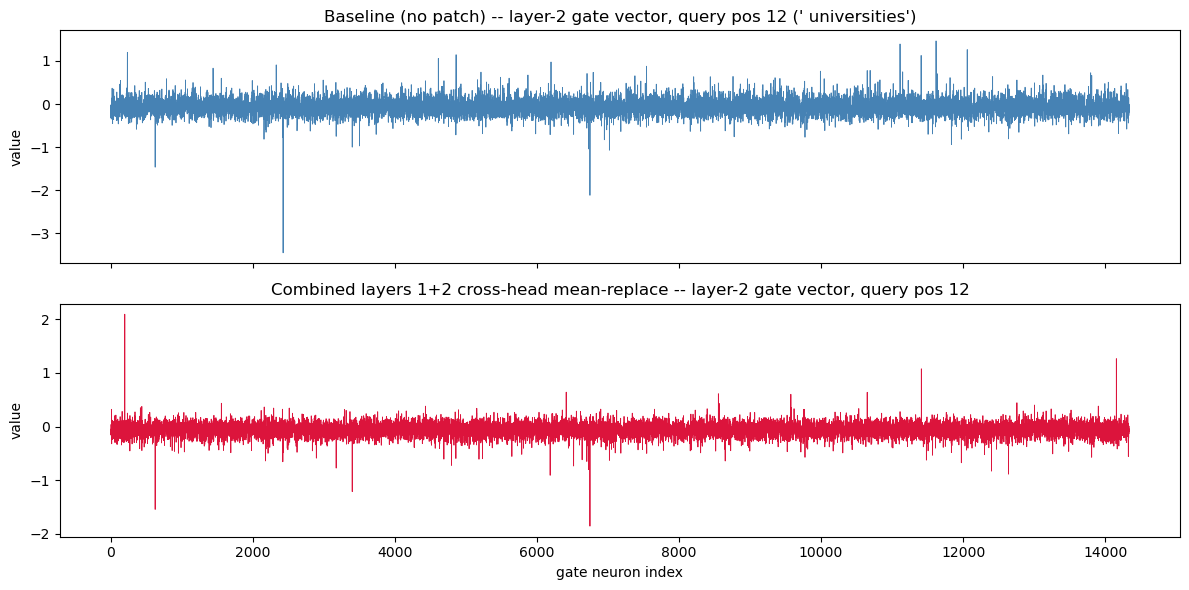

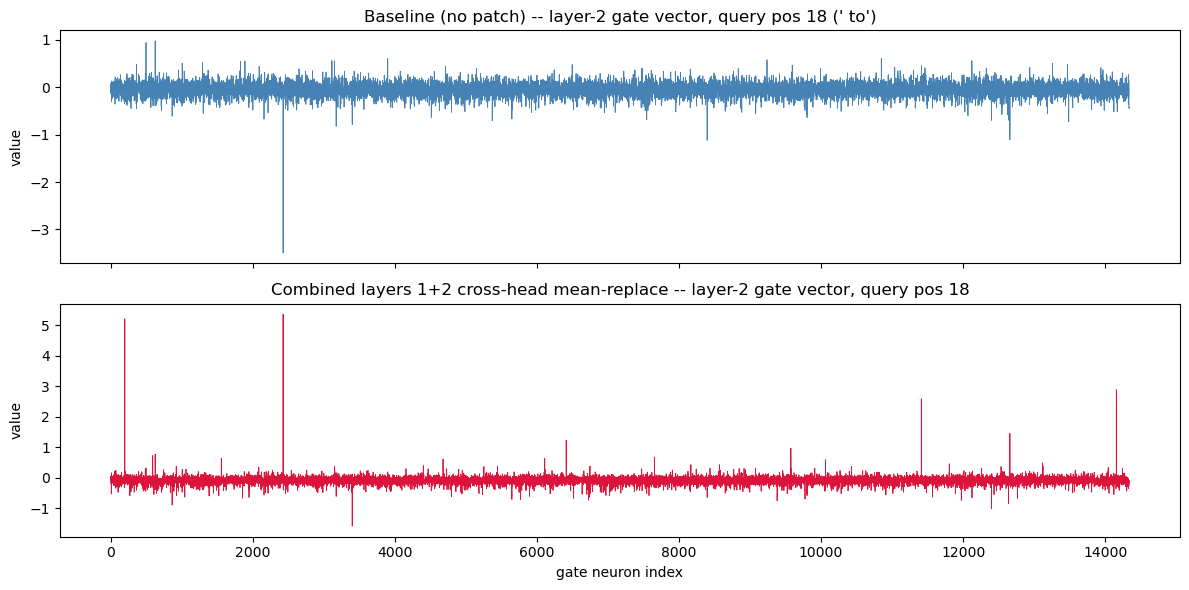

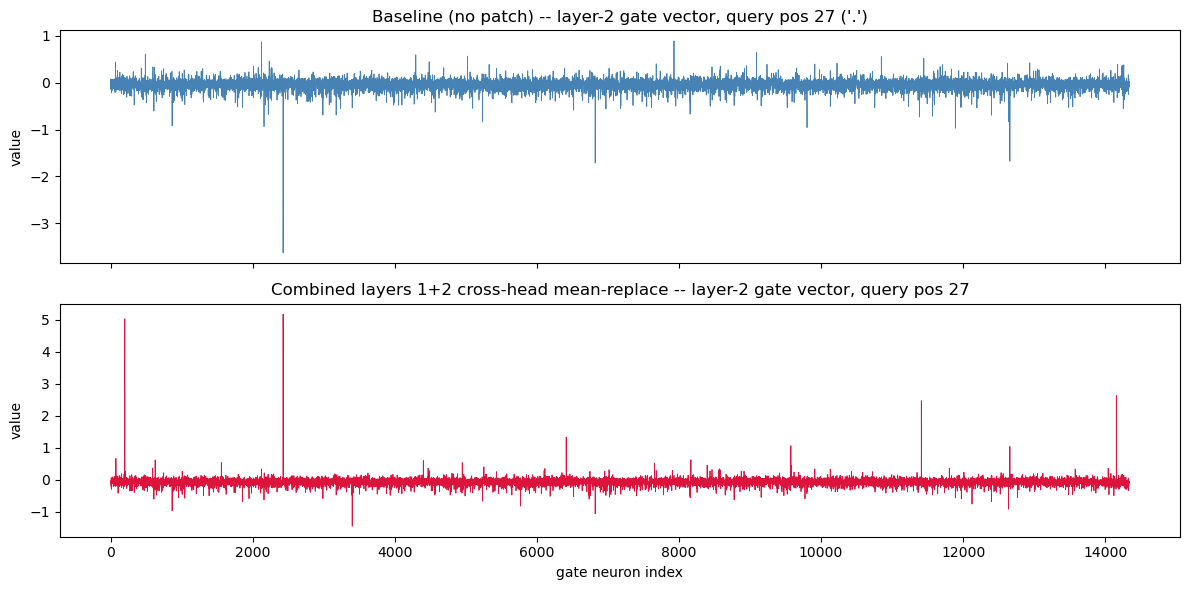

In [8]:
# Both entries come from un-patched, deterministic forward passes, so they must agree.
for q in QUERY_POSITIONS:
    a = results[q][LAYERS_TO_TEST[0]]['gate_readout_baseline']
    for L in LAYERS_TO_TEST[1:]:
        assert np.allclose(a, results[q][L]['gate_readout_baseline'], atol=1e-4), (
            f"un-patched baseline gate @ L{GATE_READOUT_LAYER} disagrees between the "
            f"L={LAYERS_TO_TEST[0]} and L={L} loop iterations at q={q}"
        )
print("baseline gate read-outs agree across loop iterations: OK")

print(f"\n=== gate[{NEURON_IDX}] across conditions and query positions ===")
print(f"    all columns read at HF layer {GATE_READOUT_LAYER} ({LAYER_LABELS[GATE_READOUT_LAYER]}); "
      f"only the PATCHED layer varies")
hdr = f"{'q':>4}{'token':>16}{'base':>12}{'L1-only':>12}{'L2-only':>12}{'combined':>12}{'flip(comb)':>12}"
print(hdr)
for q in QUERY_POSITIONS:
    base = results[q][GATE_READOUT_LAYER]['gate_readout_baseline'][NEURON_IDX]
    l1 = results[q][0]['gate_readout_intervention'][NEURON_IDX]   # patch @ HF layer 0
    l2 = results[q][1]['gate_readout_intervention'][NEURON_IDX]   # patch @ HF layer 1
    comb = results[q]['combined']['gate'][NEURON_IDX]             # patch @ HF layers 0+1
    flip = bool(np.sign(base) != np.sign(comb))
    print(f"{q:>4}{tokens_decoded[q]!r:>16}{base:>12.3f}{l1:>12.3f}{l2:>12.3f}{comb:>12.3f}{str(flip):>12}")

print(f"\n=== additivity check: does patching both layers equal the sum of the two single-layer effects? ===")
print(f"{'q':>4}{'d(L1)':>12}{'d(L2)':>12}{'d(L1)+d(L2)':>14}{'d(comb)':>12}{'interaction':>14}")
for q in QUERY_POSITIONS:
    base = results[q][GATE_READOUT_LAYER]['gate_readout_baseline'][NEURON_IDX]
    d1 = results[q][0]['gate_readout_intervention'][NEURON_IDX] - base
    d2 = results[q][1]['gate_readout_intervention'][NEURON_IDX] - base
    dc = results[q]['combined']['gate'][NEURON_IDX] - base
    print(f"{q:>4}{d1:>12.3f}{d2:>12.3f}{d1 + d2:>14.3f}{dc:>12.3f}{dc - (d1 + d2):>14.3f}")

for q in QUERY_POSITIONS:
    gate_base = results[q][GATE_READOUT_LAYER]['gate_readout_baseline']
    gate_comb = results[q]['combined']['gate']

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(gate_base, linewidth=0.6, color='steelblue')
    axes[0].set_title(f"Baseline (no patch) -- layer-2 gate vector, query pos {q} ({tokens_decoded[q]!r})")
    axes[0].set_ylabel("value")
    axes[1].plot(gate_comb, linewidth=0.6, color='crimson')
    axes[1].set_title(f"Combined layers 1+2 cross-head mean-replace -- layer-2 gate vector, query pos {q}")
    axes[1].set_xlabel("gate neuron index")
    axes[1].set_ylabel("value")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"gate_vector_layer2_q{q}.pdf"))
    plt.show()


## Step 4 — Finding MA: top-k |activation| vs. layer

For the baseline stack and each combined `q` stack, plot the top-1..5 and median
`|activation|` per layer of the residual stream. Massive activations show up as the
top-k curves detaching from the median by orders of magnitude at a particular layer.

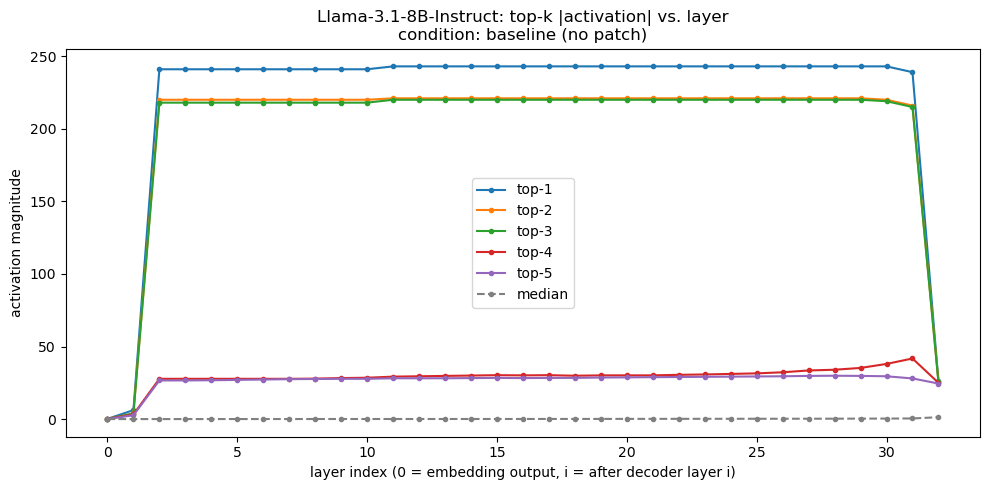

[baseline (no patch)] argmax top-1 |activation| at layer 11 (value=243.0, median=0.065, ratio=3742x)


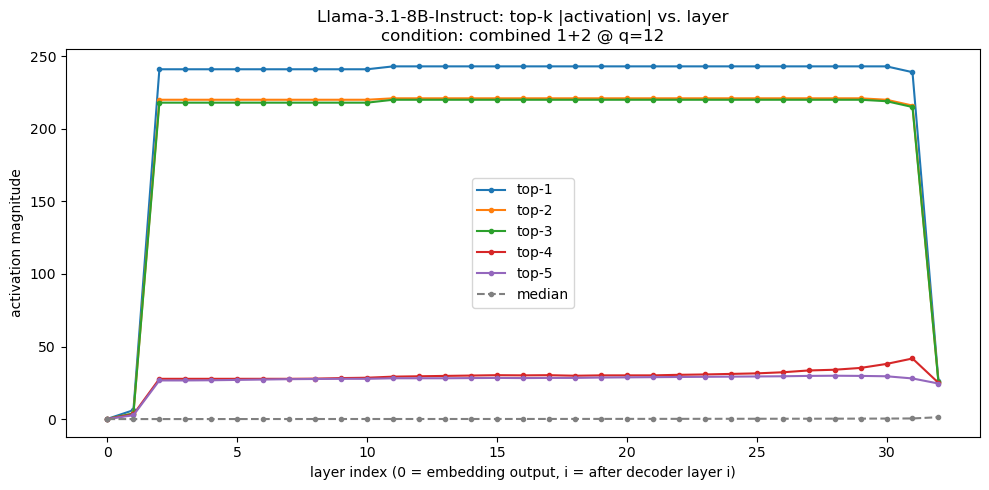

[combined 1+2 @ q=12] argmax top-1 |activation| at layer 11 (value=243.0, median=0.065, ratio=3714x)


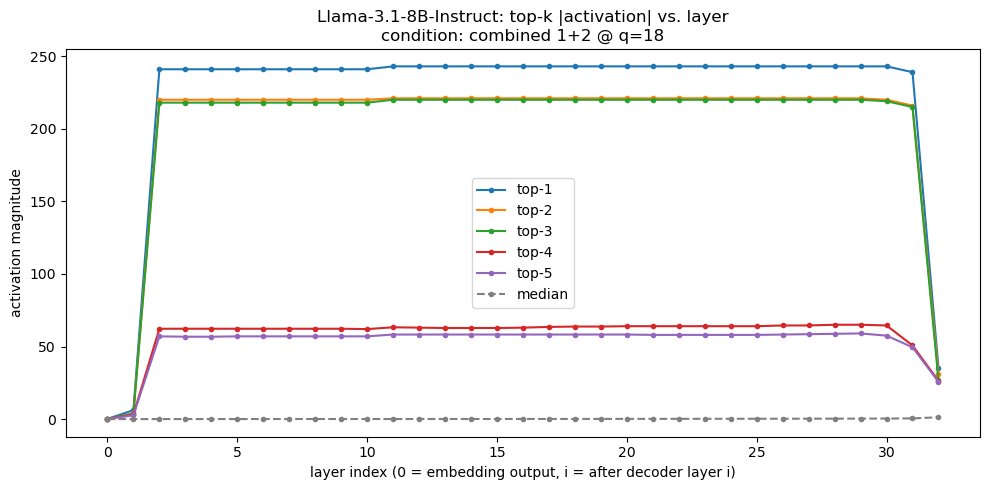

[combined 1+2 @ q=18] argmax top-1 |activation| at layer 11 (value=243.0, median=0.067, ratio=3633x)


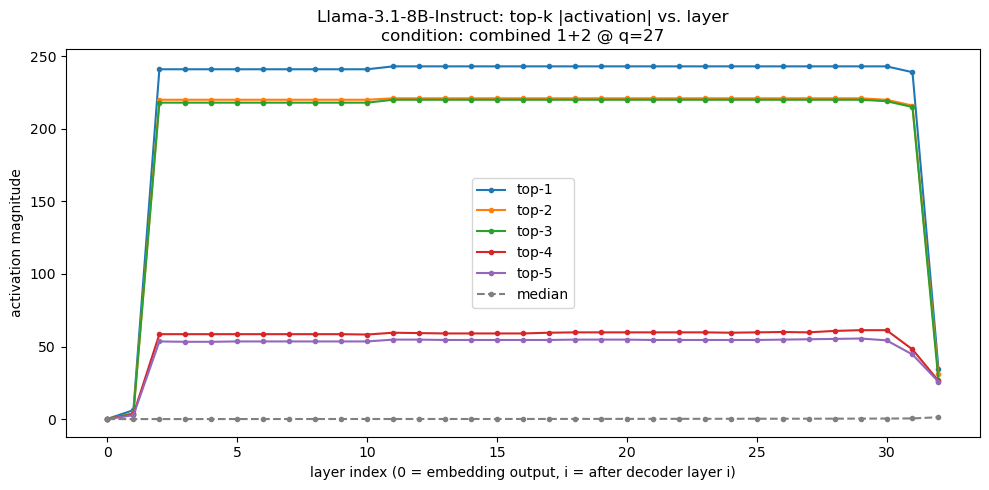

[combined 1+2 @ q=27] argmax top-1 |activation| at layer 11 (value=243.0, median=0.067, ratio=3633x)


In [9]:
def topk_layer_stats(hidden_states):
    stats = np.zeros((6, len(hidden_states)))  # rows: top1..top5, then median
    for l, h in enumerate(hidden_states):
        feat_abs = h[0].float().abs()  # (T, d)
        flat_sorted, _ = torch.sort(feat_abs.flatten(), descending=True)
        stats[:5, l] = flat_sorted[:5].cpu().numpy()
        stats[5, l] = feat_abs.median().item()
    return stats


conditions = {'baseline (no patch)': baseline_hs}
conditions.update({f"combined 1+2 @ q={q}": hidden_states_store[q] for q in QUERY_POSITIONS})

best_layer_by_cond = {}
for name, hs in conditions.items():
    stats = topk_layer_stats(hs)
    layer_axis = np.arange(len(hs))

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, lbl in enumerate(["top-1", "top-2", "top-3", "top-4", "top-5"]):
        ax.plot(layer_axis, stats[i], marker="o", markersize=3, label=lbl)
    ax.plot(layer_axis, stats[5], marker="o", markersize=3, label="median", linestyle="--", color="gray")
    ax.set_xlabel("layer index (0 = embedding output, i = after decoder layer i)")
    ax.set_ylabel("activation magnitude")
    ax.set_title(f"Llama-3.1-8B-Instruct: top-k |activation| vs. layer\ncondition: {name}")
    ax.legend()
    plt.tight_layout()
    slug = name.replace(' ', '_').replace('=', '').replace('+', '')
    plt.savefig(os.path.join(OUTPUT_DIR, f"topk_activation_by_layer_{slug}.pdf"))
    plt.show()

    best_layer = int(np.argmax(stats[0]))
    best_layer_by_cond[name] = best_layer
    print(f"[{name}] argmax top-1 |activation| at layer {best_layer} "
          f"(value={stats[0, best_layer]:.1f}, median={stats[5, best_layer]:.3f}, "
          f"ratio={stats[0, best_layer] / max(stats[5, best_layer], 1e-8):.0f}x)")

In [10]:
def find_massive_activations(h, abs_thresh=100.0, ratio_thresh=1000.0):
    # h: (T, d) tensor for a single layer. Returns (list of (token_idx, feat_idx, value), median).
    feat_abs = h.float().abs()
    med = feat_abs.median().item()
    mask = (feat_abs > abs_thresh) & (feat_abs > ratio_thresh * med)
    idxs = torch.nonzero(mask, as_tuple=False)
    res = [(int(t), int(i), feat_abs[t, i].item()) for t, i in idxs]
    res.sort(key=lambda r: -r[2])
    return res, med


ma_layer_by_cond = {}
for name, hs in conditions.items():
    LAYER_ID = best_layer_by_cond[name]  # override manually to inspect a specific layer
    h_l = hs[LAYER_ID][0]  # (T, d)
    mas, layer_median = find_massive_activations(h_l)
    ma_layer_by_cond[name] = LAYER_ID
    print(f"\n[{name}] layer {LAYER_ID} -- median |activation| = {layer_median:.4f} -- "
          f"{len(mas)} massive activation(s):")
    for t, i, v in mas:
        print(f"    token[{t:2d}]={tokens_decoded[t]!r:>16}  feature_dim={i:5d}  |activation|={v:.1f}")


[baseline (no patch)] layer 11 -- median |activation| = 0.0649 -- 3 massive activation(s):
    token[ 0]=       'Florida'  feature_dim=  788  |activation|=243.0
    token[ 0]=       'Florida'  feature_dim= 1384  |activation|=221.0
    token[ 0]=       'Florida'  feature_dim= 4062  |activation|=220.0

[combined 1+2 @ q=12] layer 11 -- median |activation| = 0.0654 -- 3 massive activation(s):
    token[ 0]=       'Florida'  feature_dim=  788  |activation|=243.0
    token[ 0]=       'Florida'  feature_dim= 1384  |activation|=221.0
    token[ 0]=       'Florida'  feature_dim= 4062  |activation|=220.0

[combined 1+2 @ q=18] layer 11 -- median |activation| = 0.0669 -- 3 massive activation(s):
    token[ 0]=       'Florida'  feature_dim=  788  |activation|=243.0
    token[ 0]=       'Florida'  feature_dim= 1384  |activation|=221.0
    token[ 0]=       'Florida'  feature_dim= 4062  |activation|=220.0

[combined 1+2 @ q=27] layer 11 -- median |activation| = 0.0669 -- 3 massive activation(s):
  

### Step 4b — 3D plot (feature dimension × token position × |activation|)

Same bar3d view as the source notebook, one per condition, at that condition's
top-1 layer. Massive activations appear as a few isolated tall spikes at specific
`(token position, feature dimension)` pairs against an otherwise flat floor.

/tmp/ipykernel_2225277/4123806719.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


saved to outputs/layers_1_and_2_mean_attn_intervention/3d_plots/llama31_8b_instruct_MA_baseline_no_patch_layer11.png


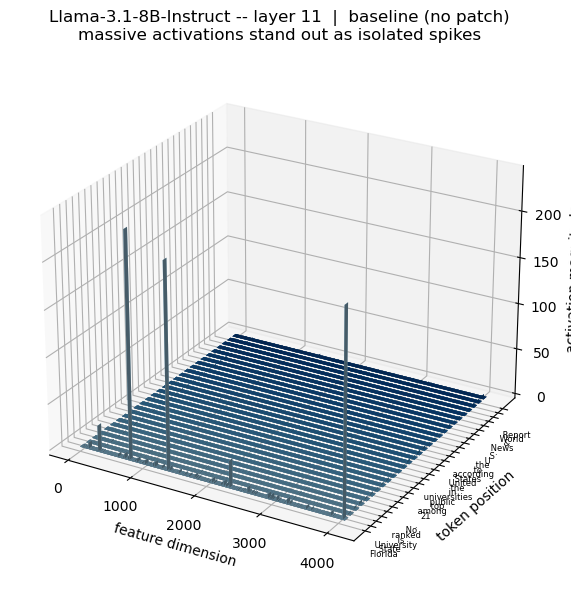

saved to outputs/layers_1_and_2_mean_attn_intervention/3d_plots/llama31_8b_instruct_MA_combined_12_@_q12_layer11.png


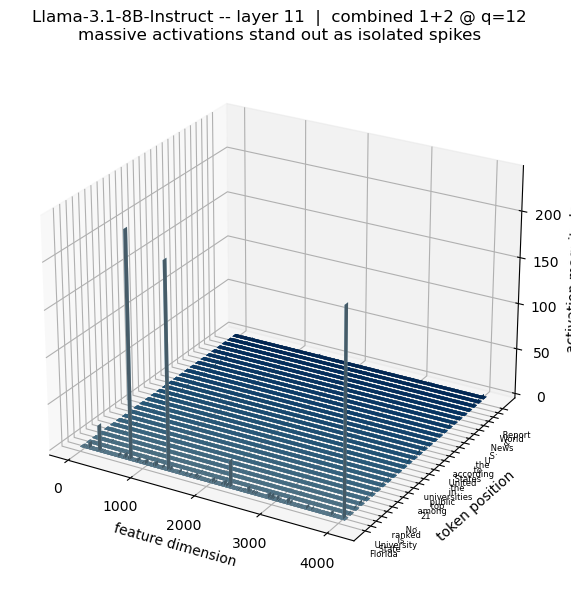

saved to outputs/layers_1_and_2_mean_attn_intervention/3d_plots/llama31_8b_instruct_MA_combined_12_@_q18_layer11.png


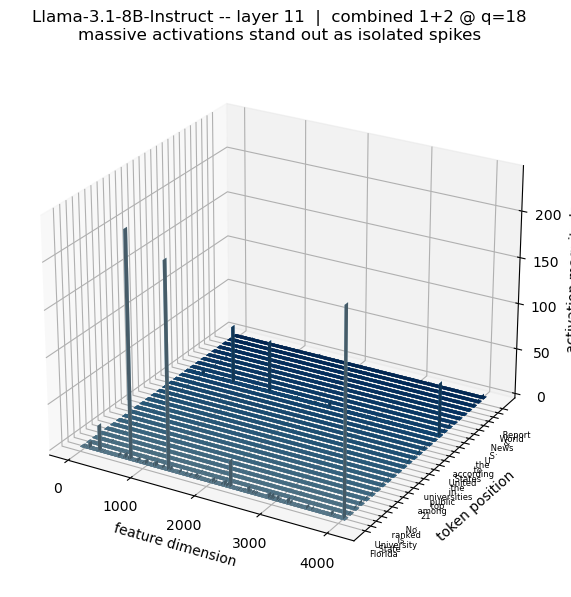

saved to outputs/layers_1_and_2_mean_attn_intervention/3d_plots/llama31_8b_instruct_MA_combined_12_@_q27_layer11.png


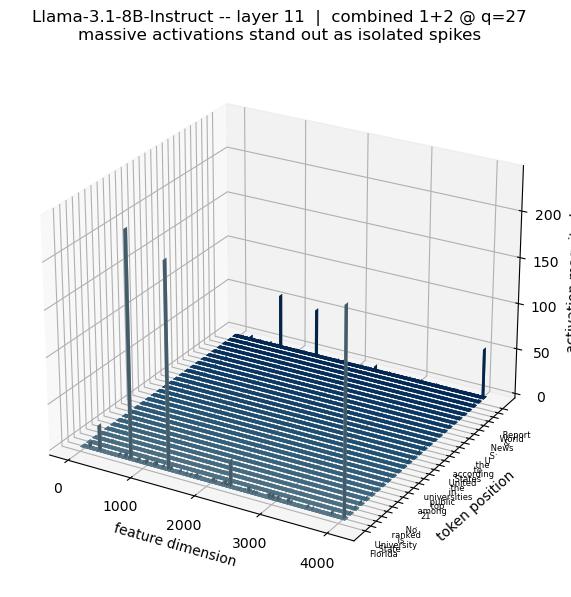

In [11]:
def plot_3d_feat(h, tokens_decoded, layer_id, model_name, title_suffix="",
                 savepath=None, elev=25, azim=-60):
    # h: (T, d) tensor (CPU, float).
    feat_abs = h.float().abs().cpu().numpy()
    T, d = feat_abs.shape

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")

    xs = np.arange(d)
    dx = np.ones(d) * 1.0
    dy = np.ones(d) * 0.6
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, T))

    for t in range(T):
        ys = np.full(d, t)
        zs = np.zeros(d)
        dz = feat_abs[t]
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[t], shade=True, edgecolor="none", alpha=0.9)

    ax.set_xlabel("feature dimension")
    ax.set_ylabel("token position")
    ax.set_zlabel("activation magnitude")
    ax.set_yticks(np.arange(T))
    ax.set_yticklabels(tokens_decoded, fontsize=6)
    ax.set_title(f"{model_name} -- layer {layer_id}{title_suffix}\n"
                 f"massive activations stand out as isolated spikes")
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"saved to {savepath}")
    plt.show()


OUTPUT_DIR_3D = f"{OUTPUT_DIR}/3d_plots"
os.makedirs(OUTPUT_DIR_3D, exist_ok=True)

for name, hs in conditions.items():
    LAYER_ID = ma_layer_by_cond[name]
    slug = name.replace(' ', '_').replace('=', '').replace('+', '').replace('(', '').replace(')', '')
    full_path = os.path.join(OUTPUT_DIR_3D, f"llama31_8b_instruct_MA_{slug}_layer{LAYER_ID}.png")
    plot_3d_feat(
        hs[LAYER_ID][0].cpu(),
        tokens_decoded,
        LAYER_ID,
        "Llama-3.1-8B-Instruct",
        title_suffix=f"  |  {name}",
        savepath=full_path,
    )

## Interpretation

- **`L1-only` / `L2-only` / `combined`** columns: whether collapsing that layer's
  attention to the cross-head average over keys `0 … q` is enough to move (or flip the
  sign of) `gate[NEURON_IDX]` at each query position. All four columns are read at
  `GATE_READOUT_LAYER` through the same `gate_proj` matrix, so only the patch location
  differs — `L1-only` is therefore a pure "does layer 1's edit reach layer 2's gate"
  propagation measurement, and `combined − L2-only` measures that propagation *on top
  of* layer 2's own local intervention.
- **Additivity check:** `d(comb) − [d(L1) + d(L2)]`. Near zero means the two
  single-layer interventions compose linearly and each layer's contribution is
  independent; a large residual means they interact — layer 1's perturbation changes
  what layer 2's own patch does.
- **Query-position dependence:** positions 12 and 18 are mid-sentence tokens; the last
  position aggregates the whole sentence. Comparing the three shows whether the
  intervention's effect on the gate read-out and on downstream massive activations
  depends on where in the sequence attention is flattened.
- **Massive-activation plots:** the top-k-vs-layer curve, the MA table, and the 3D
  bar plot show *where* (which layer, which token position, which feature dimension)
  the massive activations land under each condition. If the un-patched baseline and
  the patched conditions put their MAs at the same layer / token / feature, the
  cross-head mean-replace at layers 1–2 leaves the massive-activation mechanism
  intact; a shift means flattening early-layer attention feeds forward into it.
- **Cross-head, not cross-key** (see the header): the shared post-patch row is exactly
  what the *average* head would have produced over keys `0 … q`, so this intervention
  removes only inter-head variation, not the aggregate attention signal.
